In [1]:
import pandas as pd
import numpy as np
data=pd.read_csv('pingan_train_400.csv')
data.head()

,date,close_price
0,2020-01-02,28.50
1,2020-01-03,28.82
2,2020-01-06,28.76
3,2020-01-07,29.17
4,2020-01-08,30.10


In [2]:
price=data.loc[:,'close_price']
price_norm=price/max(price)
print(price_norm)

0      0.796312
1      0.805253
2      0.803576
3      0.815032
4      0.841017
         ...   
395    0.884605
396    0.882369
397    0.859737
398    0.870075
399    0.875384
Name: close_price, Length: 400, dtype: float64


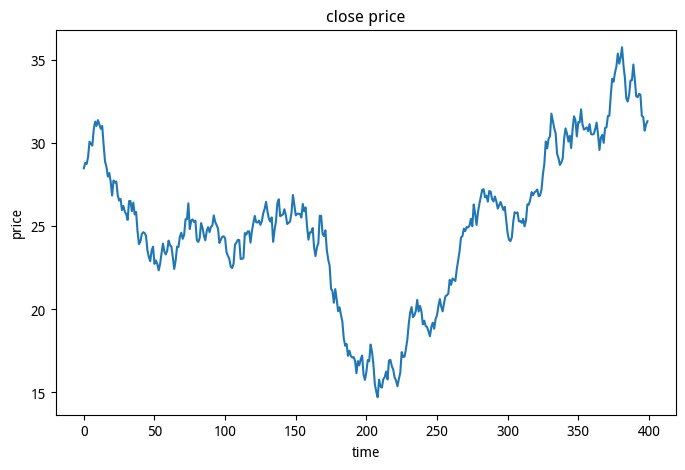

In [3]:
%matplotlib inline
from matplotlib import pyplot as plt
fig1=plt.figure(figsize=(8,5))
plt.plot(price)
plt.title('close price')
plt.xlabel('time')
plt.ylabel('price')
plt.show()

In [4]:
def extract_data(data,time_step):
    X=[]
    y=[]
    for i in range(len(data)-time_step):
        X.append([a for a in data[i:i+time_step]])
        y.append(data[i+time_step])
    X = np.array(X)
    X = X.reshape(X.shape[0], X.shape[1],1)
    return X, y

In [5]:
time_step=8
X,y=extract_data(price_norm,time_step)
y=np.array(y)
print(X.shape,len(y))

(392, 8, 1) 392


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,SimpleRNN,Input

model=Sequential()
model.add(Input(shape=(time_step,1)))
model.add(SimpleRNN(units=5,activation='relu'))
model.add(Dense(units=1,activation='linear'))
model.compile(optimizer='adam',loss='mean_squared_error')
model.summary()

2025-11-03 10:51:21.241323: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-03 10:51:21.241438: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-03 10:51:21.276349: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 5)                 35        
                                                                 
 dense (Dense)               (None, 1)                 6         
                                                                 
Total params: 41 (164.00 Byte)
Trainable params: 41 (164.00 Byte)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [7]:
model.fit(X,y,batch_size=32,epochs=400)

Epoch 1/400


I0000 00:00:1762138277.515096    1828 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


13/13 [==============================] - -5s 10ms/step - loss: 0.2964
Epoch 2/400
13/13 [==============================] - 0s 9ms/step - loss: 0.2565
Epoch 3/400
13/13 [==============================] - 0s 8ms/step - loss: 0.2190
Epoch 4/400
13/13 [==============================] - 0s 8ms/step - loss: 0.1818
Epoch 5/400
13/13 [==============================] - 0s 8ms/step - loss: 0.1465
Epoch 6/400
13/13 [==============================] - 0s 8ms/step - loss: 0.1088
Epoch 7/400
13/13 [==============================] - 0s 8ms/step - loss: 0.0683
Epoch 8/400
13/13 [==============================] - 0s 8ms/step - loss: 0.0381
Epoch 9/400
13/13 [==============================] - 0s 8ms/step - loss: 0.0194
Epoch 10/400
13/13 [==============================] - 0s 8ms/step - loss: 0.0083
Epoch 11/400
13/13 [==============================] - 0s 8ms/step - loss: 0.0033
Epoch 12/400
13/13 [==============================] - 0s 8ms/step - loss: 0.0017
Epoch 13/400
13/13 [===========================

In [8]:
y_train_predict=model.predict(X)*max(price)
y_train=y*max(price)
#print(y_train_predict,y_train)

13/13 [==============================] - 0s 2ms/step


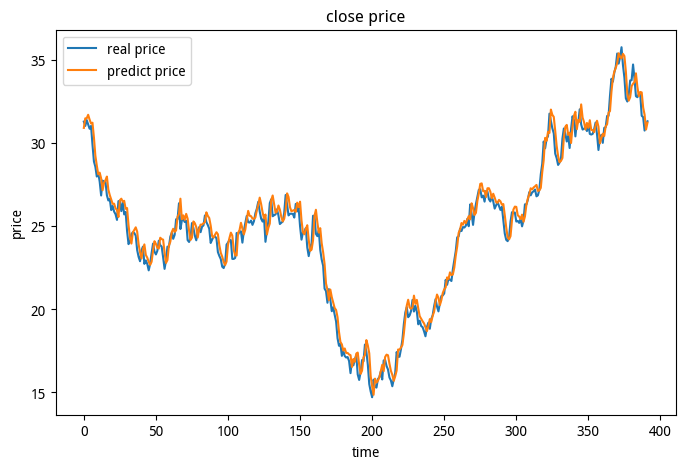

In [9]:
fig2=plt.figure(figsize=(8,5))
plt.plot(y_train,label='real price')
plt.plot(y_train_predict,label='predict price')
plt.title('close price')
plt.xlabel('time')
plt.ylabel('price')
plt.legend()
plt.show()

In [16]:
data_test=pd.read_csv('pingan_test_150.csv')
price_test= data_test.loc[:, 'close_price']
price_test_norm =price_test/max(price_test)

X_test_norm, y_test_norm = extract_data(price_test_norm,time_step)
print(X_test_norm.shape,len(y_test_norm))

(142, 8, 1) 142


In [17]:
y_test_predict=model.predict(X_test_norm)*max(price_test)
y_test=np.array(y_test_norm)*max(price_test)

5/5 [==============================] - 0s 6ms/step


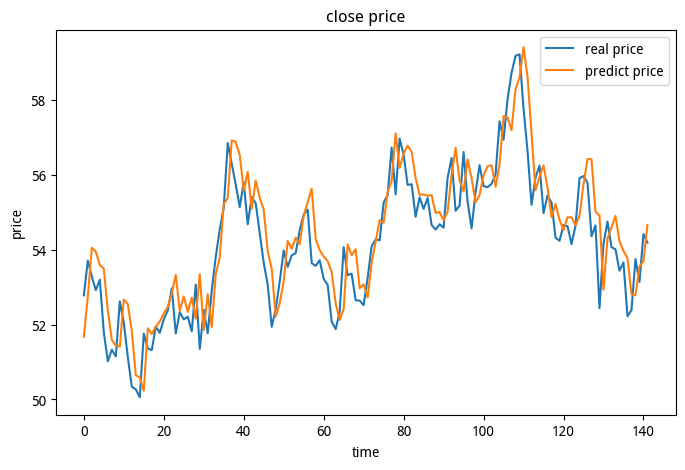

In [18]:
fig3=plt.figure(figsize=(8,5))
plt.plot(y_test,label='real price')
plt.plot(y_test_predict,label='predict price')
plt.title('close price')
plt.xlabel('time')
plt.ylabel('price')
plt.legend()
plt.show()

In [22]:
result_y_test=np.array(y_test).reshape(-1,1)
result_y_test_predict=y_test_predict
print(result_y_test.shape,result_y_test_predict.shape)
result=np.concatenate((result_y_test,result_y_test_predict),axis=1)
print(result.shape)
result=pd.DataFrame(result,columns=['real_price_test','predict_price_test'])
result.to_csv('pingan_predict_test.csv')

(142, 1) (142, 1)
(142, 2)
